## **<font color="red">Logistic Regression</font>**
### **<font color="blue">Method 02: Scikit Learn</font>**

Accuracy: 99.33%
Weights: [[ 1.50264608 -0.85652421]]
Bias: [-0.53750207]


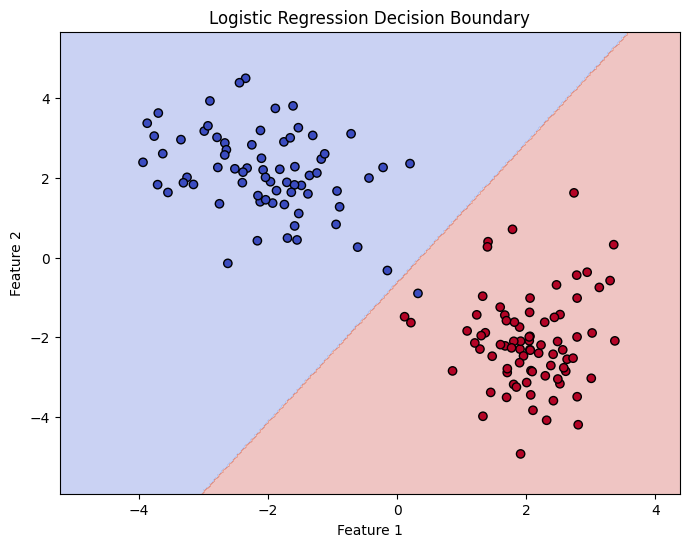

In [1]:
import numpy as np
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

# -------------------------------
# Dataset
# -------------------------------
np.random.seed(41)
X, y = make_classification(
    n_samples=500,
    n_features=2,
    n_informative=2,
    n_redundant=0,
    n_classes=2,
    n_clusters_per_class=1,
    random_state=41,
    class_sep=2.0
)

# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

# -------------------------------
# Model Training
# -------------------------------
lr = LogisticRegression()
lr.fit(X_train, y_train)

# -------------------------------
# Prediction & Accuracy
# -------------------------------
y_pred = lr.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy * 100:.2f}%")

# -------------------------------
# Weights & Bias
# -------------------------------
print("Weights:", lr.coef_)
print("Bias:", lr.intercept_)

# -------------------------------
# Plot
# -------------------------------
x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 300),
                     np.linspace(y_min, y_max, 300))
Z = lr.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)

plt.figure(figsize=(8, 6))
plt.contourf(xx, yy, Z, alpha=0.3, cmap='coolwarm')
plt.scatter(X_test[:, 0], X_test[:, 1], c=y_test, cmap='coolwarm', edgecolors='k')
plt.title("Logistic Regression Decision Boundary")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.show()


## **<font color="blue">Compare Perceptron Trick & Scikit-Learn Logistic Regression</font>**

Perceptron learned bias: -0.10000000000000003
Perceptron learned weights: [ 0.07061018 -0.06882265]
Perceptron train accuracy: 98.57%
Perceptron test accuracy:  97.33%

LogisticRegression test accuracy: 99.33%
LogisticRegression weights (coef): [[ 1.50264608 -0.85652421]]
LogisticRegression bias (intercept): [-0.53750207]


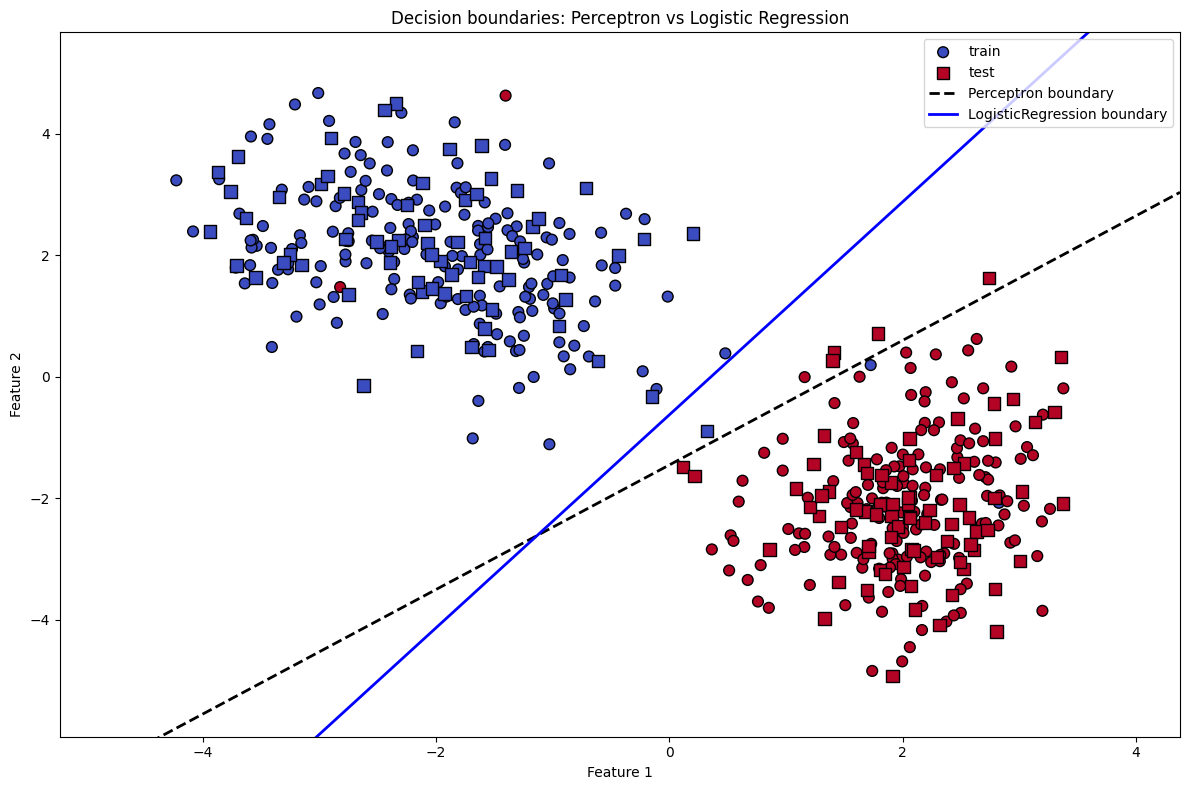

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

# ---------------------------
# Perceptron (simple online)
# ---------------------------
def perceptron(X_train, y_train, lr=0.1, epochs=1000, shuffle=True):
    """
    Online perceptron for labels {0,1}.
    Returns: bias(float), w (ndarray shape (n_features,)), full_weights (ndarray [bias, w1, w2,...])
    """
    X = np.asarray(X_train, dtype=float)
    y = np.asarray(y_train, dtype=int).ravel()
    n_samples, n_features = X.shape

    # add bias column
    Xb = np.insert(X, 0, 1.0, axis=1)  # shape (n_samples, n_features+1)

    # weights: bias + features
    weights = np.zeros(n_features + 1, dtype=float)

    for epoch in range(int(epochs)):
        idx = np.arange(n_samples)
        if shuffle:
            np.random.shuffle(idx)
        updates = 0
        for i in idx:
            xi = Xb[i]
            yi = int(y[i])
            score = float(np.dot(xi, weights))
            y_hat = 1 if score >= 0 else 0
            err = yi - y_hat
            if err != 0:
                weights += lr * err * xi
                updates += 1
        if updates == 0:
            # converged early
            break

    bias = float(weights[0])
    w = weights[1:].copy()
    return bias, w, weights.copy()

def perceptron_predict(X_test, weights_full):
    X = np.asarray(X_test, dtype=float)
    if X.ndim == 1:
        X = X.reshape(1, -1)
    Xb = np.insert(X, 0, 1.0, axis=1)
    scores = Xb.dot(weights_full)
    return (scores >= 0).astype(int)

# ---------------------------
# Helper: safe linear boundary plot
# ---------------------------
def plot_linear_boundary(ax, w_full, x_min, x_max, y_min, y_max, label, color='k', linestyle='--', linewidth=2):
    """
    Draws the line for w0 + w1*x + w2*y = 0.
    Handles near-vertical lines safely.
    w_full: [bias, w1, w2]
    """
    w0, w1, w2 = float(w_full[0]), float(w_full[1]), float(w_full[2])
    eps = 1e-9
    if abs(w2) > eps:
        x_vals = np.array([x_min, x_max])
        y_vals = -(w0 + w1 * x_vals) / w2
        ax.plot(x_vals, y_vals, label=label, color=color, linestyle=linestyle, linewidth=linewidth)
    elif abs(w1) > eps:
        xv = -w0 / w1
        ax.plot([xv, xv], [y_min, y_max], label=label, color=color, linestyle=linestyle, linewidth=linewidth)
    else:
        # degenerates to nothing
        pass

# ---------------------------
# Main: dataset, train, compare
# ---------------------------
def main(random_state=41):
    np.random.seed(random_state)

    # Dataset (2D for plotting)
    X, y = make_classification(n_samples=500, n_features=2, n_informative=2, n_redundant=0,
                               n_classes=2, n_clusters_per_class=1, random_state=random_state, class_sep=2.0)

    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

    # Train Perceptron
    p_bias, p_w, p_weights_full = perceptron(X_train, y_train, lr=0.1, epochs=1000, shuffle=True)
    print("Perceptron learned bias:", p_bias)
    print("Perceptron learned weights:", p_w)

    # Evaluate Perceptron
    train_preds_p = perceptron_predict(X_train, p_weights_full).ravel()
    test_preds_p = perceptron_predict(X_test, p_weights_full).ravel()
    train_acc_p = np.mean(train_preds_p == y_train)
    test_acc_p  = np.mean(test_preds_p  == y_test)
    print(f"Perceptron train accuracy: {train_acc_p*100:.2f}%")
    print(f"Perceptron test accuracy:  {test_acc_p*100:.2f}%")

    # Train Logistic Regression
    lr_model = LogisticRegression()
    lr_model.fit(X_train, y_train)

    # Evaluate Logistic Regression
    y_pred_lr = lr_model.predict(X_test)
    acc_lr = accuracy_score(y_test, y_pred_lr)
    print(f"\nLogisticRegression test accuracy: {acc_lr*100:.2f}%")
    print("LogisticRegression weights (coef):", lr_model.coef_)
    print("LogisticRegression bias (intercept):", lr_model.intercept_)

    # Prepare boundaries for plotting
    pad = 1.0
    x_min, x_max = X[:,0].min() - pad, X[:,0].max() + pad
    y_min, y_max = X[:,1].min() - pad, X[:,1].max() + pad

    fig, ax = plt.subplots(figsize=(12,8))

    # Plot data
    ax.scatter(X_train[:,0], X_train[:,1], c=y_train, cmap='coolwarm', marker='o', edgecolor='k', s=60, label='train')
    ax.scatter(X_test[:,0], X_test[:,1], c=y_test, cmap='coolwarm', marker='s', edgecolor='k', s=80, label='test')

    # Perceptron boundary (p_weights_full contains bias first)
    plot_linear_boundary(ax, p_weights_full, x_min, x_max, y_min, y_max,
                         label='Perceptron boundary', color='black', linestyle='--', linewidth=2)

    # Logistic boundary: make [bias, w1, w2]
    log_bias = float(lr_model.intercept_.ravel()[0])
    log_w = lr_model.coef_.ravel()
    log_weights_full = np.array([log_bias, log_w[0], log_w[1]])
    plot_linear_boundary(ax, log_weights_full, x_min, x_max, y_min, y_max,
                         label='LogisticRegression boundary', color='blue', linestyle='-', linewidth=2)

    ax.set_xlim(x_min, x_max)
    ax.set_ylim(y_min, y_max)
    ax.set_xlabel("Feature 1")
    ax.set_ylabel("Feature 2")
    ax.set_title("Decision boundaries: Perceptron vs Logistic Regression")
    ax.legend(loc='upper right')
    plt.tight_layout()
    plt.show()

if __name__ == "__main__":
    main()


### **n_class = 10**

Perceptron learned bias: -0.30000000000000004
Perceptron learned weights: [ 0.41397049 -0.19581049]
Perceptron train accuracy: 98.86%
Perceptron test accuracy:  100.00%

LogisticRegression test accuracy: 100.00%
LogisticRegression weights (coef): [[ 0.47417825 -0.42493894]]
LogisticRegression bias (intercept): [-0.11618568]


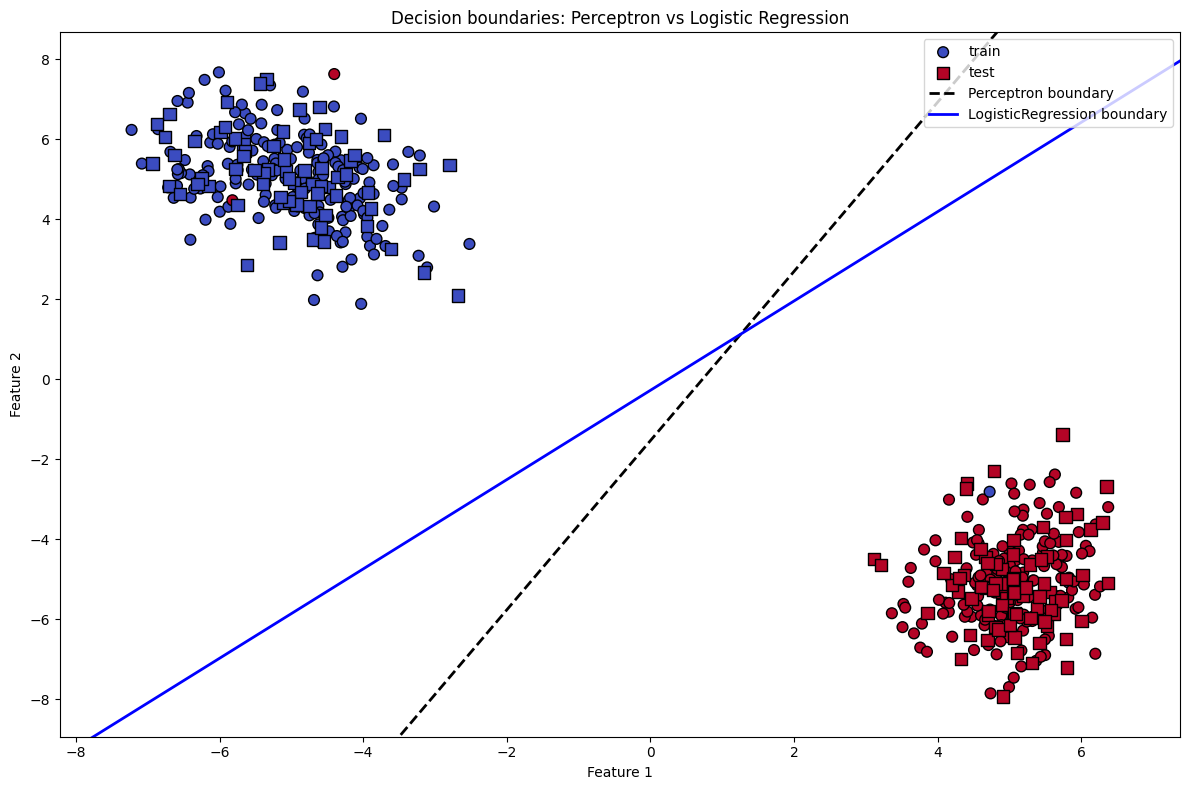

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

# ---------------------------
# Perceptron (simple online)
# ---------------------------
def perceptron(X_train, y_train, lr=0.1, epochs=1000, shuffle=True):
    """
    Online perceptron for labels {0,1}.
    Returns: bias(float), w (ndarray shape (n_features,)), full_weights (ndarray [bias, w1, w2,...])
    """
    X = np.asarray(X_train, dtype=float)
    y = np.asarray(y_train, dtype=int).ravel()
    n_samples, n_features = X.shape

    # add bias column
    Xb = np.insert(X, 0, 1.0, axis=1)  # shape (n_samples, n_features+1)

    # weights: bias + features
    weights = np.zeros(n_features + 1, dtype=float)

    for epoch in range(int(epochs)):
        idx = np.arange(n_samples)
        if shuffle:
            np.random.shuffle(idx)
        updates = 0
        for i in idx:
            xi = Xb[i]
            yi = int(y[i])
            score = float(np.dot(xi, weights))
            y_hat = 1 if score >= 0 else 0
            err = yi - y_hat
            if err != 0:
                weights += lr * err * xi
                updates += 1
        if updates == 0:
            # converged early
            break

    bias = float(weights[0])
    w = weights[1:].copy()
    return bias, w, weights.copy()

def perceptron_predict(X_test, weights_full):
    X = np.asarray(X_test, dtype=float)
    if X.ndim == 1:
        X = X.reshape(1, -1)
    Xb = np.insert(X, 0, 1.0, axis=1)
    scores = Xb.dot(weights_full)
    return (scores >= 0).astype(int)

# ---------------------------
# Helper: safe linear boundary plot
# ---------------------------
def plot_linear_boundary(ax, w_full, x_min, x_max, y_min, y_max, label, color='k', linestyle='--', linewidth=2):
    """
    Draws the line for w0 + w1*x + w2*y = 0.
    Handles near-vertical lines safely.
    w_full: [bias, w1, w2]
    """
    w0, w1, w2 = float(w_full[0]), float(w_full[1]), float(w_full[2])
    eps = 1e-9
    if abs(w2) > eps:
        x_vals = np.array([x_min, x_max])
        y_vals = -(w0 + w1 * x_vals) / w2
        ax.plot(x_vals, y_vals, label=label, color=color, linestyle=linestyle, linewidth=linewidth)
    elif abs(w1) > eps:
        xv = -w0 / w1
        ax.plot([xv, xv], [y_min, y_max], label=label, color=color, linestyle=linestyle, linewidth=linewidth)
    else:
        # degenerates to nothing
        pass

# ---------------------------
# Main: dataset, train, compare
# ---------------------------
def main(random_state=41):
    np.random.seed(random_state)

    # Dataset (2D for plotting)
    X, y = make_classification(n_samples=500, n_features=2, n_informative=2, n_redundant=0,
                               n_classes=2, n_clusters_per_class=1, random_state=random_state, class_sep=5)

    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)
    
    # Train Perceptron
    p_bias, p_w, p_weights_full = perceptron(X_train, y_train, lr=0.1, epochs=1000, shuffle=True)
    print("Perceptron learned bias:", p_bias)
    print("Perceptron learned weights:", p_w)

    # Evaluate Perceptron
    train_preds_p = perceptron_predict(X_train, p_weights_full).ravel()
    test_preds_p = perceptron_predict(X_test, p_weights_full).ravel()
    train_acc_p = np.mean(train_preds_p == y_train)
    test_acc_p  = np.mean(test_preds_p  == y_test)
    print(f"Perceptron train accuracy: {train_acc_p*100:.2f}%")
    print(f"Perceptron test accuracy:  {test_acc_p*100:.2f}%")

    # Train Logistic Regression
    lr_model = LogisticRegression()
    lr_model.fit(X_train, y_train)

    # Evaluate Logistic Regression
    y_pred_lr = lr_model.predict(X_test)
    acc_lr = accuracy_score(y_test, y_pred_lr)
    print(f"\nLogisticRegression test accuracy: {acc_lr*100:.2f}%")
    print("LogisticRegression weights (coef):", lr_model.coef_)
    print("LogisticRegression bias (intercept):", lr_model.intercept_)

    # Prepare boundaries for plotting
    pad = 1.0
    x_min, x_max = X[:,0].min() - pad, X[:,0].max() + pad
    y_min, y_max = X[:,1].min() - pad, X[:,1].max() + pad

    fig, ax = plt.subplots(figsize=(12,8))

    # Plot data
    ax.scatter(X_train[:,0], X_train[:,1], c=y_train, cmap='coolwarm', marker='o', edgecolor='k', s=60, label='train')
    ax.scatter(X_test[:,0], X_test[:,1], c=y_test, cmap='coolwarm', marker='s', edgecolor='k', s=80, label='test')

    # Perceptron boundary (p_weights_full contains bias first)
    plot_linear_boundary(ax, p_weights_full, x_min, x_max, y_min, y_max,
                         label='Perceptron boundary', color='black', linestyle='--', linewidth=2)

    # Logistic boundary: make [bias, w1, w2]
    log_bias = float(lr_model.intercept_.ravel()[0])
    log_w = lr_model.coef_.ravel()
    log_weights_full = np.array([log_bias, log_w[0], log_w[1]])
    plot_linear_boundary(ax, log_weights_full, x_min, x_max, y_min, y_max,
                         label='LogisticRegression boundary', color='blue', linestyle='-', linewidth=2)

    ax.set_xlim(x_min, x_max)
    ax.set_ylim(y_min, y_max)
    ax.set_xlabel("Feature 1")
    ax.set_ylabel("Feature 2")
    ax.set_title("Decision boundaries: Perceptron vs Logistic Regression")
    ax.legend(loc='upper right')
    plt.tight_layout()
    plt.show()

if __name__ == "__main__":
    main()
